# Imports & Setup

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.1 MB/s eta 0:00:00


In [ ]:
import random
from typing import Literal
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import cv2
from torchvision import tv_tensors
from torchvision.transforms import v2 as T

from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torch
from tqdm import tqdm
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [ ]:
# Sets random seeds for reproducibility
def set_seed(seed):
    # Set seed for PyTorch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        # Set seed for all available GPUs
        torch.cuda.manual_seed_all(seed)

    # Set seed for NumPy
    np.random.seed(seed)

    # Set seed for Python's built-in random module
    random.seed(seed)

    # Enable deterministic algorithms for reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Use deterministic algorithms where available
    torch.use_deterministic_algorithms(True)

# Set random seeds
my_seed = 42
set_seed(my_seed)

# Load in dataset

In [ ]:
# Mount Google Drive
from google.colab import drive
drive_root = '/content/drive'
drive.mount(drive_root)

Mounted at /content/drive


In [ ]:
# Set file paths
DRIVE_ROOT = "/content/drive/MyDrive"
DATA_ROOT = f"{DRIVE_ROOT}/COMP-SCI 5567 - Deep Learning/Project/raw_data"
MOT16_ZIP = f"{DATA_ROOT}/MOT16.zip"

COLAB_ROOT = f"/content"
MOT16_ROOT = f"{COLAB_ROOT}/MOT16"
MOT16_TRAIN = f"{MOT16_ROOT}/train"
MOT16_TEST = f"{MOT16_ROOT}/test"

In [ ]:
# Copy MOT16.zip from Google Drive to Colag
!cp "{MOT16_ZIP}" "/content/MOT16.zip"

In [ ]:
# Unzip MOT16.zip
!unzip "/content/MOT16.zip"

Streaming output truncated to the last 5000 lines.
  inflating: MOT16/train/MOT16-11/img1/000188.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000188.jpg  
  inflating: MOT16/train/MOT16-11/img1/000836.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000836.jpg  
  inflating: MOT16/train/MOT16-11/img1/000639.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000639.jpg  
  inflating: MOT16/train/MOT16-11/img1/000605.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000605.jpg  
  inflating: MOT16/train/MOT16-11/img1/000163.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000163.jpg  
  inflating: MOT16/train/MOT16-11/img1/000177.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000177.jpg  
  inflating: MOT16/train/MOT16-11/img1/000611.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000611.jpg  
  inflating: MOT16/train/MOT16-05/det/det.txt  
  inflating: __MACOSX/MOT16/train/MOT16-05/det/._det.txt  
  inflating: MOT16/train/MOT16-05/gt/

# Data Preparation

In [ ]:
# Dataset for MOT16 train and val
class MOT16Dataset(Dataset):
  def __init__(self, root_dir=MOT16_TRAIN, split: Literal["train", "val"] ="train", split_ratio=0.7, transforms=None):
    self.root_dir = root_dir
    self.split = split
    self.split_ratio = split_ratio
    self.transforms = transforms

    self.samples = []

    all_video_folders = sorted(os.listdir(root_dir))

    for folder in all_video_folders:
      folder_path = os.path.join(root_dir, folder)
      img_dir = os.path.join(folder_path, "img1")
      gt_path = os.path.join(folder_path, "gt", "gt.txt")

      images = sorted(os.listdir(img_dir))

      gt_data = self.parse_gt(gt_path)

      split_point = int(len(images) * split_ratio)
      if self.split == "train":
        images = images[:split_point]
      elif self.split == "val":
        images = images[split_point:]

      print(f"Split: {self.split} | Folder: {folder} | Num imgs: {len(images)}")

      for img in images:
        frame_id = int(img.split(".")[0])

        self.samples.append({
            "img_path": os.path.join(img_dir, img),
            "bounding_boxes": gt_data.get(frame_id, [])
        })

  def parse_gt(self, file_path):
    data = {}

    with open(file_path, 'r') as f:
      for line in f:
        fields = line.strip().split(',')

        if len(fields) < 9:
          continue

        frame, track_id, x, y, w, h, conf, cls, vis = map(float, fields)

        frame = int(frame)
        track_id = int(track_id)
        cls = int(cls)

        x1 = x
        y1 = y
        x2 = x + w
        y2 = y + h

        if frame not in data:
            data[frame] = []

        data[frame].append({
            "id": track_id,
            "bbox": [x1, y1, x2, y2],
            "class": cls,
            "confidence": conf,
            "visibility": vis
        })

    return data

  def __getitem__(self, idx):
    sample = self.samples[idx]
    img_path = sample["img_path"]
    img = Image.open(img_path).convert("RGB")

    width, height = img.size

    ped_objs = [
      obj for obj in sample["bounding_boxes"]
      if (int(obj["class"]) == 1 or int(obj["class"]) == 2 or int(obj["class"]) == 7)
      and int(obj["confidence"]) == 1
      and obj["visibility"] >= 0.25
    ]

    boxes_list = [obj["bbox"] for obj in ped_objs]

    if len(boxes_list) > 0:
        boxes = torch.as_tensor(boxes_list, dtype=torch.float32)
    else:
        boxes = torch.zeros((0, 4), dtype=torch.float32)

    boxes = tv_tensors.BoundingBoxes(
        boxes,
        format="XYXY",
        canvas_size=(height, width)
    )

    target = {
        "boxes": boxes,
        "labels": torch.ones((len(boxes),), dtype=torch.int64),
        "image_id": torch.tensor([idx]),
    }

    if self.transforms:
      img, target = self.transforms(img, target)

    return img, target

  def __len__(self):
    return len(self.samples)

# Data Augmentation

In [ ]:
base_transforms = T.Compose([
  T.ToImage(),
  T.ToDtype(torch.float32, scale=True),

  T.ClampBoundingBoxes(),
])

aug_transforms = T.Compose([
  T.RandomHorizontalFlip(p=0.5),

  T.ColorJitter(
    brightness=0.05,
    contrast=0.05,
    saturation=0.05
  ),

  T.ToImage(),
  T.ToDtype(torch.float32, scale=True),

  T.ClampBoundingBoxes(),
  T.SanitizeBoundingBoxes(),
])

# Model Fine Tuning

## Load and prep model

In [ ]:
# Config

# Train val split
train_split_ratio = 0.8 # percent of data used for training

# Training
num_classes = 2 # number of classes to train on: 0 = background, 1 = person
num_epochs = 25
batch_size = 4
num_workers = 2
patience = 5 # Stop if no improvement after
min_delta = 0.005 # Amt decrease in loss needed for action
num_batches = -1 # Use for testing. For training with all batches use -1

# Optimizer
learning_rate = 0.005
momentum = 0.9
weight_decay = 0.0005

# Learning rate scheduler
step_size = 5
gamma = 0.1

# Saves
best_model_filepath = "/content/drive/MyDrive/COMP-SCI 5567 - Deep Learning/Project/rcnn_model/best_model"
checkpoint_filepath = "/content/drive/MyDrive/COMP-SCI 5567 - Deep Learning/Project/rcnn_model/training_checkpoints"

In [ ]:
# Load Faster R-CNN model
model = fasterrcnn_resnet50_fpn(pretrained=True)

# Set num features to detect
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Freeze backbone layers
for param in model.backbone.parameters():
  param.requires_grad = False

# Only fine-tune the heads for classification and mask prediction
params_to_optimize = [p for p in model.parameters() if p.requires_grad]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 125MB/s]


In [ ]:
# Load in datasets
mot16_train_data = MOT16Dataset(split="train", split_ratio=train_split_ratio, transforms=aug_transforms)
mot16_val_data = MOT16Dataset(split="val", split_ratio=train_split_ratio, transforms=base_transforms)

Split: train | Folder: MOT16-02 | Num imgs: 480
Split: train | Folder: MOT16-04 | Num imgs: 840
Split: train | Folder: MOT16-05 | Num imgs: 669
Split: train | Folder: MOT16-09 | Num imgs: 420
Split: train | Folder: MOT16-10 | Num imgs: 523
Split: train | Folder: MOT16-11 | Num imgs: 720
Split: train | Folder: MOT16-13 | Num imgs: 600
Split: val | Folder: MOT16-02 | Num imgs: 120
Split: val | Folder: MOT16-04 | Num imgs: 210
Split: val | Folder: MOT16-05 | Num imgs: 168
Split: val | Folder: MOT16-09 | Num imgs: 105
Split: val | Folder: MOT16-10 | Num imgs: 131
Split: val | Folder: MOT16-11 | Num imgs: 180
Split: val | Folder: MOT16-13 | Num imgs: 150


In [ ]:
print("train:", len(mot16_train_data))
print("val:", len(mot16_val_data))

print(f"% val = {len(mot16_val_data) / (len(mot16_train_data) + len(mot16_val_data)) * 100:.1f}%")

train: 4252
val: 1064
% val = 20.0%


In [ ]:
# Create dataloaders
train_dataloader = DataLoader(
    mot16_train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    collate_fn=lambda x: tuple(zip(*x))
    )

val_dataloader = DataLoader(
    mot16_val_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    collate_fn=lambda x: tuple(zip(*x))
    )

In [ ]:
# Set device to GPU if available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device) # Move model to device
print("Device:", device)

Device: cuda


In [ ]:
optimizer = torch.optim.SGD(
    params_to_optimize,
    lr=learning_rate,
    momentum=momentum,
    weight_decay=weight_decay
    )

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=step_size,
    gamma=gamma
    )

## Fine Tune & Save

In [ ]:
# Saves model
def save_model(model, filepath="/content/", model_name="model"):
  torch.save(model.state_dict(), f"{filepath}/{model_name}_state_dict.pth") # Saves state dict
  # torch.save(model, f"{filepath}/{model_name}.pth") # Saves entire model
  print("Model saved!")

In [ ]:
def save_checkpoint(epoch, model_state_dict, optimizer_state_dict, loss, results, filepath):
    state = {
        'epoch': epoch,
        'model_state_dict': model_state_dict,
        'optimizer_state_dict': optimizer_state_dict,
        'loss': loss,
        'results': results,
    }
    torch.save(state, filepath)
    print(f"Checkpoint saved to {filepath}")

In [ ]:
def evaluate_map(model, data_loader, device, epoch):

    model.eval()

    metric = MeanAveragePrecision(iou_type="bbox")

    pbar = tqdm(
            data_loader,
            desc=f"Epoch {epoch+1}/{num_epochs} [Val Metric]",
            leave=True,
            dynamic_ncols=True
            )
    with torch.no_grad():
        for i, (images, targets) in enumerate(pbar):

            images = [img.to(device) for img in images]

            # move targets to device
            targets_gpu = [{k: v.to(device) for k, v in t.items()} for t in targets]

            preds = model(images)

            # move predictions back to cpu for metric
            preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
            targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]

            metric.update(preds_cpu, targets_cpu)

            if num_batches != -1 and i >= num_batches:
              break

    results = metric.compute()

    return results

In [ ]:
@torch.no_grad()
def validation(model, data_loader, device, epoch):
    total_loss = 0
    total_samples = 0
    model.train()

    pbar = tqdm(
        data_loader,
        desc=f"Epoch {epoch+1}/{num_epochs} [Val]",
        leave=True,
        dynamic_ncols=True
        )
    for i, (images, targets) in enumerate(pbar):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        total_loss += losses.item() * len(images)
        total_samples += len(images)

        pbar.set_postfix(loss=(total_loss / total_samples))

        if num_batches != -1 and i >= num_batches:
          break

    avg_loss = total_loss / total_samples

    return avg_loss

In [ ]:
# Training loop
training_losses = []
val_losses = []
val_results_list = []
best_val_loss = float("inf")
epochs_completed = 0
last_model_saved_epoch = 0
epochs_no_improve = 0

for epoch in range(num_epochs):
    pbar = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch+1}/{num_epochs} [Train]",
        leave=True,
        dynamic_ncols=True
        )
    model.train()
    total_loss = 0
    total_samples = 0
    for i, (images, targets) in enumerate(pbar):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        total_loss += losses.item() * len(images)
        total_samples += len(images)

        pbar.set_postfix(loss=(total_loss / total_samples))

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        if num_batches != -1 and i >= num_batches:
          break

    avg_loss = total_loss / total_samples

    # Step the LR scheduler
    lr_scheduler.step()
    training_losses.append(avg_loss)

    # Validation
    val_loss = validation(model, val_dataloader, device, epoch)
    val_losses.append(val_loss)

    # Evaluation
    val_results = evaluate_map(model=model, data_loader=val_dataloader, device=device, epoch=epoch)
    val_results_list.append(val_results)

    val_map = val_results['map'].item()

    epochs_completed += 1
    print(f"Epoch {epoch+1} completed | Train loss: {avg_loss:.4f} | Val loss: {val_loss:.4f} | Val mAP: {val_map:.4f}")

    save_checkpoint(
        epoch=epochs_completed,
        model_state_dict=model.state_dict(),
        optimizer_state_dict=optimizer.state_dict(),
        loss=val_loss,
        results=val_results,
        filepath=f"{checkpoint_filepath}/save_checkpoint_{epochs_completed}.pth")

    # Model save if better than before
    if val_loss < best_val_loss - min_delta:
      best_val_loss = val_loss
      epochs_no_improve = 0
      save_model(model, filepath=best_model_filepath, model_name="fine_tuned_faster_rcnn")
      last_model_saved_epoch = epoch + 1
    else: # Early stopping if no improvements
      epochs_no_improve += 1
      if epochs_no_improve >= patience:
        print(f"Training stopped early at epoch {epochs_completed}")
        break
      else:
        print(f"No improvement, early stopping may happen after {patience - epochs_no_improve} more epochs if no improvements")

Epoch 1/25 [Val Metric]: 100%|██████████| 266/266 [03:16<00:00,  1.36it/s]


Epoch 1 completed | Train loss: 0.5302 | Val loss: 0.5027 | Val mAP: 0.5899
Checkpoint saved to /content/drive/MyDrive/COMP-SCI 5567 - Deep Learning/Project/rcnn_model/training_checkpoints/save_checkpoint_1.pth
Model saved!


Epoch 2/25 [Val Metric]: 100%|██████████| 266/266 [03:16<00:00,  1.35it/s]


Epoch 2 completed | Train loss: 0.4557 | Val loss: 0.4930 | Val mAP: 0.6025
Checkpoint saved to /content/drive/MyDrive/COMP-SCI 5567 - Deep Learning/Project/rcnn_model/training_checkpoints/save_checkpoint_2.pth
Model saved!


Epoch 3/25 [Val Metric]: 100%|██████████| 266/266 [03:18<00:00,  1.34it/s]


...

Epoch 9 completed | Train loss: 0.3576 | Val loss: 0.4680 | Val mAP: 0.6250
Checkpoint saved to /content/drive/MyDrive/COMP-SCI 5567 - Deep Learning/Project/rcnn_model/training_checkpoints/save_checkpoint_9.pth
No improvement, early stopping may happen after 2 more epochs if no improvements


Epoch 10/25 [Val Metric]: 100%|██████████| 266/266 [03:16<00:00,  1.35it/s]


Epoch 10 completed | Train loss: 0.3552 | Val loss: 0.4636 | Val mAP: 0.6259
Checkpoint saved to /content/drive/MyDrive/COMP-SCI 5567 - Deep Learning/Project/rcnn_model/training_checkpoints/save_checkpoint_10.pth
No improvement, early stopping may happen after 1 more epochs if no improvements


Epoch 11/25 [Val Metric]: 100%|██████████| 266/266 [03:16<00:00,  1.35it/s]


Epoch 11 completed | Train loss: 0.3519 | Val loss: 0.4634 | Val mAP: 0.6254
Checkpoint saved to /content/drive/MyDrive/COMP-SCI 5567 - Deep Learning/Project/rcnn_model/training_checkpoints/save_checkpoint_11.pth
Training stopped early at epoch 11


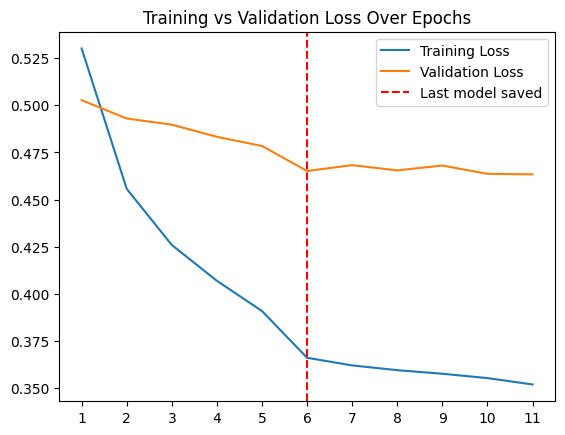

In [ ]:
# Plots training and validation losses
sns.lineplot(x=range(1, len(training_losses) + 1), y=training_losses, label="Training Loss")
sns.lineplot(x=range(1, len(val_losses) + 1), y=val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss Over Epochs")
plt.xticks(range(1, len(val_losses) + 1))
plt.axvline(x=last_model_saved_epoch, color='r', linestyle='--', label='Last model saved')
plt.legend()
plt.show()

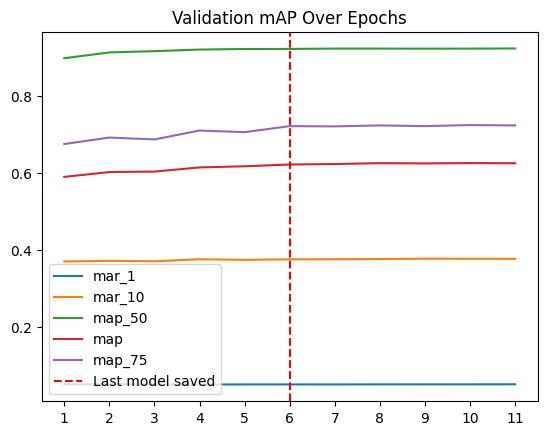

In [ ]:
# Plots training and validation maps
metrics_to_plot = ["mar_1", "mar_10", "map_50", "map", "map_75"]

for metric in metrics_to_plot:
  sns.lineplot(x=range(1, len(val_results_list) + 1), y=[r[metric].item() for r in val_results_list], label=metric)

plt.title("Validation mAP Over Epochs")
plt.xticks(range(1, len(val_results_list)  + 1))
plt.axvline(x=last_model_saved_epoch, color='r', linestyle='--', label='Last model saved')
plt.legend()
plt.show()

In [ ]:
from google.colab import runtime
runtime.unassign()